# Modelado del Efecto Mpemba en Sistemas Coloidales
## Kumar & Bechhoefer, *Nature* **584**, 64 (2020) — con QCPINN

Este notebook reproduce y extiende el análisis del paper. Se aplican **cuatro** arquitecturas de ML:

| Modelo | Pregunta que responde |
|--------|----------------------|
| **Neural ODE** (RK4) | ¿Qué dinámica continua $dD/dt = f_\\theta(D)$ subyace a las curvas? |
| **PINN** | ¿Puede una red respetar $dD/dt \\le 0$ mientras ajusta los datos? |
| **PySR** | ¿Qué forma analítica tiene $\\dot{D}(D)$ según regresión simbólica? |
| **QCPINN** | ¿Puede un circuito variacional cuántico (VQC) aprender la dinámica con restricción física? |

> La **QCPINN** (Quantum-Classical PINN) combina un VQC de 4 qubits (PennyLane) con capas clásicas y penalización de monotonicidad idéntica a la PINN clásica. Su arquitectura se visualiza tanto con PennyLane como con Qiskit.


## 0. Instalación e importaciones

In [1]:
# Descomentar si faltan dependencias
# !pip install pennylane pennylane-lightning pylatexenc qiskit qiskit-aer pysr torch scipy matplotlib

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

# ── Quantum ────────────────────────────────────────────────────────────────
import pennylane as qml
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter as QiskitParameter

print(f"PyTorch   : {torch.__version__}")
print(f"PennyLane : {qml.__version__}")

import qiskit
print(f"Qiskit    : {qiskit.__version__}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDispositivo de cómputo: {device}")


PyTorch   : 2.12.0+cu130
PennyLane : 0.45.0
Qiskit    : 2.4.1

Dispositivo de cómputo: cuda


## 1. Carga de datos y exploración inicial

Los datos provienen de la simulación Langevin del paper. Si no se dispone del CSV real, se genera una versión sintética con parámetros del paper ($\\lambda_2 \\approx 5$, $\\alpha = 3$).

In [2]:
# ─── Intentar leer CSV real, si no existe generar sintético ─────────────────
try:
    df    = pd.read_csv('distances.csv')
    t_np  = df['t'].values.astype(np.float32)
    Dh_np = df['D_L1_h'].values.astype(np.float32)
    Dw_np = df['D_L1_w'].values.astype(np.float32)
    Dc_np = df['D_L1_c'].values.astype(np.float32)
    print("CSV 'distances.csv' cargado correctamente.")
except FileNotFoundError:
    print("CSV no encontrado — generando datos sintéticos con parámetros del paper.")
    np.random.seed(42)
    t_np    = np.linspace(0, 0.20, 201).astype(np.float32)
    lam2    = 5.0
    noise   = 0.003
    # Sistema caliente: a2 ≈ 0 (strong Mpemba) → decae rápido via λ3
    Dh_np = (0.9 * np.exp(-12.0 * t_np) + 0.35 * np.exp(-lam2 * t_np)
             + 0.02 + noise * np.random.randn(len(t_np))).clip(0).astype(np.float32)
    # Sistema cálido: dominado por λ2
    Dw_np = (0.65 * np.exp(-lam2 * t_np)
             + 0.02 + noise * np.random.randn(len(t_np))).clip(0).astype(np.float32)
    Dc_np = (noise * np.abs(np.random.randn(len(t_np)))).astype(np.float32)

t  = torch.tensor(t_np).view(-1, 1)
y  = torch.tensor(np.stack([Dh_np, Dw_np], axis=1))

# ─── Detección del cruce (efecto Mpemba) ─────────────────────────────────────
diff      = Dh_np - Dw_np
cross_idx = np.where(np.diff(np.sign(diff)))[0]
t_cross   = t_np[cross_idx] if len(cross_idx) else np.array([])

print(f"Puntos temporales:  {len(t_np)}")
print(f"Rango de t:         {t_np[0]:.4f} → {t_np[-1]:.4f} s  |  Δt = {t_np[1]-t_np[0]:.4f} s")
print(f"D_h(0) = {Dh_np[0]:.4f}   D_w(0) = {Dw_np[0]:.4f}")
print(f"D_inf (hot)  ≈ {Dh_np[-20:].mean():.5f} ± {Dh_np[-20:].std():.5f}")
print(f"D_inf (warm) ≈ {Dw_np[-20:].mean():.5f} ± {Dw_np[-20:].std():.5f}")
if len(t_cross):
    print(f"Cruce(s) detectados en t* ≈ {t_cross} s  → Efecto Mpemba ✓")
else:
    print("Sin cruce detectado")


CSV 'distances.csv' cargado correctamente.
Puntos temporales:  201
Rango de t:         0.0000 → 0.5000 s  |  Δt = 0.0025 s
D_h(0) = 1.4945   D_w(0) = 1.1085
D_inf (hot)  ≈ 0.62533 ± 0.00030
D_inf (warm) ≈ 0.56485 ± 0.00022
Cruce(s) detectados en t* ≈ [0.03   0.0425] s  → Efecto Mpemba ✓


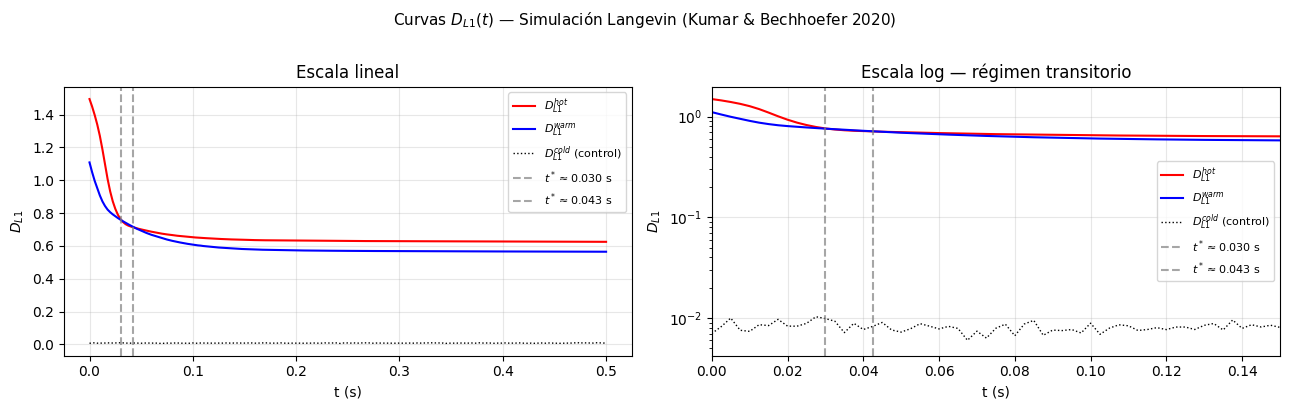

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, logscale in zip(axes, [False, True]):
    ax.plot(t_np, Dh_np, 'r-',  lw=1.5, label=r'$D_{L1}^{hot}$')
    ax.plot(t_np, Dw_np, 'b-',  lw=1.5, label=r'$D_{L1}^{warm}$')
    ax.plot(t_np, Dc_np, 'k:',  lw=1,   label=r'$D_{L1}^{cold}$ (control)')
    for tc in t_cross:
        ax.axvline(tc, color='gray', ls='--', alpha=0.7,
                   label=f'$t^* \\approx {tc:.3f}$ s')
    ax.set_xlabel('t (s)'); ax.set_ylabel(r'$D_{L1}$')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    if logscale:
        ax.set_yscale('log'); ax.set_xlim(0, 0.15)
        ax.set_title('Escala log — régimen transitorio')
    else:
        ax.set_title('Escala lineal')

plt.suptitle('Curvas $D_{L1}(t)$ — Simulación Langevin (Kumar & Bechhoefer 2020)',
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


## 2. Neural ODE con integrador RK4

Aprendemos $f_\\theta$ tal que $\\dot{D} = f_\\theta(D)$, integrando con **Runge-Kutta de orden 4** (error local $O(\\Delta t^5)$).

### Arquitectura (Neural ODE)

```
D(t₀) ∈ ℝ²  →  ODEFunc (fc₃₂→fc₃₂→fc₂)  →  RK4  →  D(t) ∈ ℝ²
```


In [4]:
# ─── Arquitectura Neural ODE ────────────────────────────────────────────────
class ODEFunc(nn.Module):
    """Aproxima dD/dt = f_theta(D).  Entrada/salida: (2,)"""
    def __init__(self, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2)
        )
    def forward(self, state):
        return self.net(state)

def rk4_integrate(func, y0, t_vec):
    t_flat = t_vec.squeeze()
    ys = [y0]
    y_cur = y0
    for i in range(1, len(t_flat)):
        dt = (t_flat[i] - t_flat[i-1]).item()
        k1 = func(y_cur)
        k2 = func(y_cur + 0.5 * dt * k1)
        k3 = func(y_cur + 0.5 * dt * k2)
        k4 = func(y_cur + dt * k3)
        y_cur = y_cur + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        ys.append(y_cur)
    return torch.stack(ys)

torch.manual_seed(42)
ode_func      = ODEFunc(hidden=32)
optimizer_ode = torch.optim.Adam(ode_func.parameters(), lr=5e-3)
scheduler_ode = torch.optim.lr_scheduler.StepLR(optimizer_ode, step_size=300, gamma=0.5)
criterion     = nn.MSELoss()

history_ode = []
for epoch in range(5000):
    optimizer_ode.zero_grad()
    y_pred_ode = rk4_integrate(ode_func, y[0], t)
    loss = criterion(y_pred_ode, y)
    loss.backward()
    optimizer_ode.step()
    scheduler_ode.step()
    history_ode.append(loss.item())
    if epoch % 1000 == 0 or epoch == 4999:
        print(f'Epoch {epoch:4d} | Loss: {loss.item():.6f}')


Epoch    0 | Loss: 0.447733
Epoch 1000 | Loss: 0.001917
Epoch 2000 | Loss: 0.001520
Epoch 3000 | Loss: 0.001466
Epoch 4000 | Loss: 0.001458
Epoch 4999 | Loss: 0.001456


### Visualización de la arquitectura Neural ODE

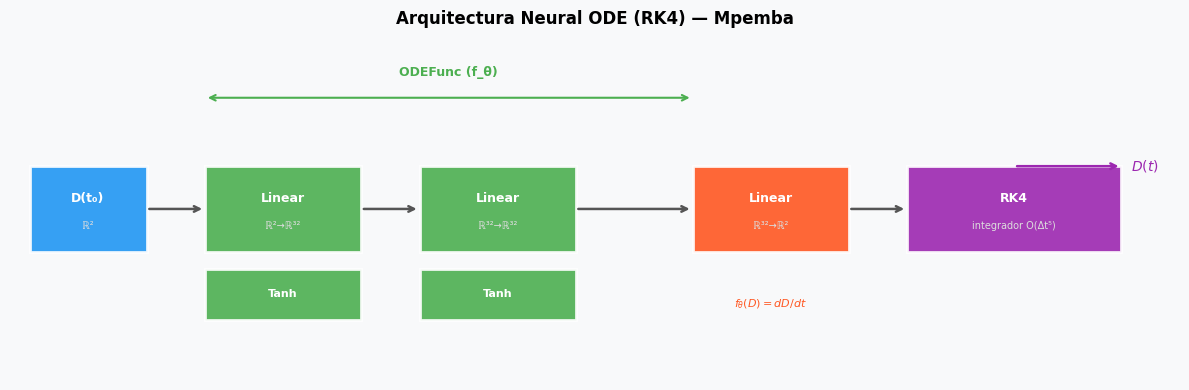

In [5]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

def draw_neural_ode_arch():
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.set_xlim(0, 12); ax.set_ylim(0, 4); ax.axis('off')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')

    colors = {'input': '#2196F3', 'hidden': '#4CAF50', 'output': '#FF5722',
              'integrator': '#9C27B0', 'arrow': '#555555'}
    
    def box(x, y, w, h, label, sub='', color='#4CAF50', fontsize=9):
        rect = plt.Rectangle((x, y), w, h, facecolor=color, edgecolor='white',
                              linewidth=2, alpha=0.9, zorder=3)
        ax.add_patch(rect)
        ax.text(x + w/2, y + h/2 + (0.12 if sub else 0), label,
                ha='center', va='center', fontsize=fontsize,
                color='white', fontweight='bold', zorder=4)
        if sub:
            ax.text(x + w/2, y + h/2 - 0.2, sub,
                    ha='center', va='center', fontsize=7, color='#ddd', zorder=4)
    
    def arrow(x1, x2, y=2.0, color='#555555'):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8), zorder=5)

    box(0.2, 1.5, 1.2, 1.0, 'D(t₀)', 'ℝ²', colors['input'])
    arrow(1.4, 2.0)
    box(2.0, 1.5, 1.6, 1.0, 'Linear', 'ℝ²→ℝ³²', colors['hidden'])
    box(2.0, 0.7, 1.6, 0.6, 'Tanh', '', colors['hidden'], fontsize=8)
    arrow(3.6, 4.2)
    box(4.2, 1.5, 1.6, 1.0, 'Linear', 'ℝ³²→ℝ³²', colors['hidden'])
    box(4.2, 0.7, 1.6, 0.6, 'Tanh', '', colors['hidden'], fontsize=8)
    arrow(5.8, 7.0)
    box(7.0, 1.5, 1.6, 1.0, 'Linear', 'ℝ³²→ℝ²', '#FF5722')
    ax.text(7.8, 0.85, r'$f_\theta(D) = dD/dt$', ha='center', fontsize=8,
            color='#FF5722', fontstyle='italic')
    arrow(8.6, 9.2)
    box(9.2, 1.5, 2.2, 1.0, 'RK4', 'integrador O(Δt⁵)', colors['integrator'])
    ax.annotate('', xy=(11.4, 2.5), xytext=(10.3, 2.5),
                arrowprops=dict(arrowstyle='->', color='#9C27B0', lw=1.8), zorder=5)
    ax.text(11.5, 2.5, r'$D(t)$', va='center', fontsize=10, color='#9C27B0',
            fontweight='bold')
    
    # Bracket ODEFunc
    ax.annotate('', xy=(7.0, 3.3), xytext=(2.0, 3.3),
                arrowprops=dict(arrowstyle='<->', color='#4CAF50', lw=1.5))
    ax.text(4.5, 3.55, 'ODEFunc (f_θ)', ha='center', fontsize=9,
            color='#4CAF50', fontweight='bold')

    ax.set_title('Arquitectura Neural ODE (RK4) — Mpemba', fontsize=12,
                 fontweight='bold', pad=10)
    plt.tight_layout(); plt.show()

draw_neural_ode_arch()


## 3. PINN con restricción termodinámica

$$
\\mathcal{L} = \\lambda_{\\text{data}}\\,\\mathcal{L}_{\\text{MSE}}
+ \\lambda_{\\text{phys}}\\,\\mathcal{L}_{\\text{phys}}
$$

con $\\mathcal{L}_{\\text{phys}} = \\frac{1}{N}\\sum_i [\\max(0, \\dot{D}_h)]^2 + [\\max(0, \\dot{D}_w)]^2$


In [6]:
class PINN(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),      nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2)
        )
    def forward(self, t_in):
        return self.net(t_in)

def pinn_loss(model, t_data, y_data, t_phys, lambda_data=1.0, lambda_phys=0.5):
    y_pred = model(t_data)
    l_data = nn.MSELoss()(y_pred, y_data)
    t_p = t_phys.clone().requires_grad_(True)
    y_p = model(t_p)
    dD_dt_h = torch.autograd.grad(y_p[:, 0].sum(), t_p,
                                   create_graph=True, retain_graph=True)[0]
    dD_dt_w = torch.autograd.grad(y_p[:, 1].sum(), t_p,
                                   create_graph=True, retain_graph=True)[0]
    loss_phys = (torch.relu(dD_dt_h)**2).mean() + (torch.relu(dD_dt_w)**2).mean()
    total = lambda_data * l_data + lambda_phys * loss_phys
    return total, l_data, loss_phys

torch.manual_seed(42)
pinn           = PINN(hidden=64)
optimizer_pinn = torch.optim.Adam(pinn.parameters(), lr=1e-3)
scheduler_pinn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pinn, T_max=2000, eta_min=1e-5)
t_phys       = t.clone()
history_pinn = []

for epoch in range(5000):
    optimizer_pinn.zero_grad()
    loss, l_d, l_p = pinn_loss(pinn, t, y, t_phys)
    loss.backward()
    optimizer_pinn.step()
    scheduler_pinn.step()
    history_pinn.append((loss.item(), l_d.item(), l_p.item()))
    if epoch % 1000 == 0 or epoch == 4999:
        print(f'Epoch {epoch:4d} | Total: {loss.item():.5f} '
              f'| Data: {l_d.item():.5f}  | Phys: {l_p.item():.5f}')


Epoch    0 | Total: 0.55301 | Data: 0.55123  | Phys: 0.00355
Epoch 1000 | Total: 0.00706 | Data: 0.00706  | Phys: 0.00000
Epoch 2000 | Total: 0.00338 | Data: 0.00337  | Phys: 0.00002
Epoch 3000 | Total: 0.00123 | Data: 0.00122  | Phys: 0.00002
Epoch 4000 | Total: 0.00006 | Data: 0.00006  | Phys: 0.00000
Epoch 4999 | Total: 0.00004 | Data: 0.00004  | Phys: 0.00000


### Visualización de la arquitectura PINN

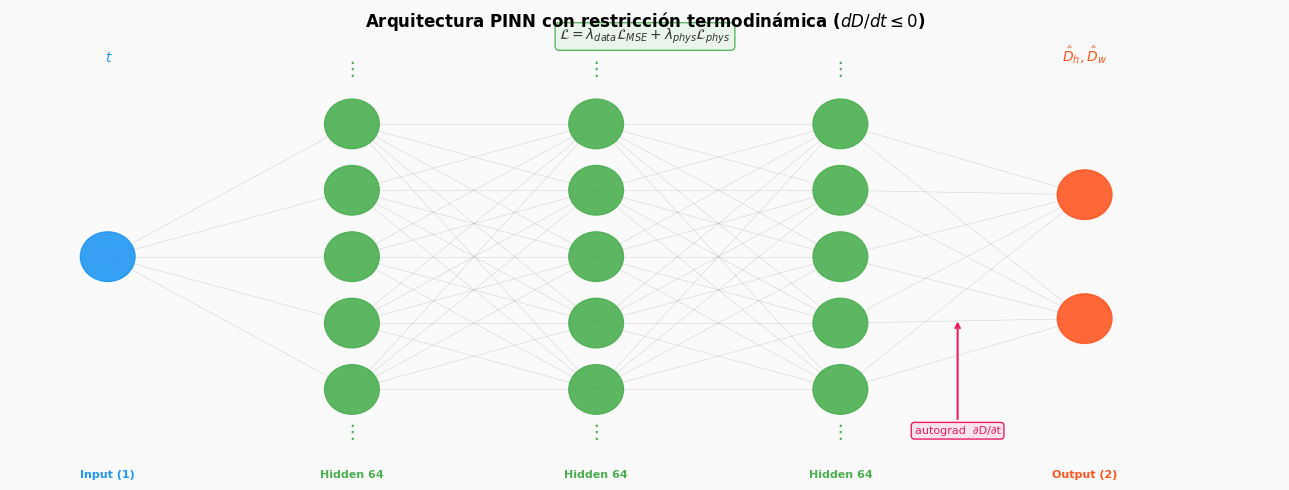

In [7]:
def draw_pinn_arch():
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.set_xlim(0, 13); ax.set_ylim(0, 5); ax.axis('off')
    ax.set_facecolor('#fafafa'); fig.patch.set_facecolor('#fafafa')

    def neuron(cx, cy, r=0.28, color='#4CAF50', label='', fontsize=7):
        c = plt.Circle((cx, cy), r, color=color, zorder=3, alpha=0.9)
        ax.add_patch(c)
        if label:
            ax.text(cx, cy, label, ha='center', va='center',
                    fontsize=fontsize, color='white', fontweight='bold', zorder=4)

    def layer_label(x, y, text, color='#333'):
        ax.text(x, y, text, ha='center', va='center', fontsize=8.5,
                color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=color, alpha=0.85))

    # Neurons
    layers = {
        'Input (1)':  {'x': 1.0,  'n': 1,  'ys': [2.5], 'color': '#2196F3'},
        'Hidden 64':  {'x': 3.5,  'n': 5,  'ys': np.linspace(1.0, 4.0, 5), 'color': '#4CAF50'},
        'Hidden 64 ': {'x': 6.0,  'n': 5,  'ys': np.linspace(1.0, 4.0, 5), 'color': '#4CAF50'},
        'Hidden 64  ':{'x': 8.5,  'n': 5,  'ys': np.linspace(1.0, 4.0, 5), 'color': '#4CAF50'},
        'Output (2)': {'x': 11.0, 'n': 2,  'ys': [1.8, 3.2], 'color': '#FF5722'},
    }

    layer_xs = sorted(set(v['x'] for v in layers.values()))
    # Draw connections
    lk = list(layers.keys())
    for i in range(len(lk)-1):
        la = layers[lk[i]]; lb = layers[lk[i+1]]
        for ya in la['ys']:
            for yb in lb['ys']:
                ax.plot([la['x'], lb['x']], [ya, yb], 'gray', lw=0.4, alpha=0.3, zorder=1)

    # Draw neurons
    for name, info in layers.items():
        for y_n in info['ys']:
            neuron(info['x'], y_n, color=info['color'])
        dots_y = info['ys']
        if info['n'] == 5:
            ax.text(info['x'], 0.45, '⋮', ha='center', fontsize=14, color=info['color'])
            ax.text(info['x'], 4.55, '⋮', ha='center', fontsize=14, color=info['color'])
        label_txt = name.strip()
        ax.text(info['x'], 0.0, label_txt, ha='center', fontsize=8,
                color=info['color'], fontweight='bold')

    # Labels above
    ax.text(1.0,  4.7, 't', ha='center', fontsize=10, fontstyle='italic', color='#2196F3')
    ax.text(11.0, 4.7, r'$\hat{D}_h,\hat{D}_w$', ha='center', fontsize=10, color='#FF5722')

    # Physics loss annotation
    ax.annotate('autograd  ∂D/∂t', xy=(9.7, 1.8), xytext=(9.7, 0.5),
                arrowprops=dict(arrowstyle='->', color='#E91E63', lw=1.5),
                fontsize=8, color='#E91E63', ha='center',
                bbox=dict(boxstyle='round', facecolor='#FCE4EC', edgecolor='#E91E63'))

    ax.text(6.5, 4.95, r'$\mathcal{L} = \lambda_{data}\mathcal{L}_{MSE} + \lambda_{phys}\mathcal{L}_{phys}$',
            ha='center', fontsize=10, color='#333',
            bbox=dict(boxstyle='round', facecolor='#E8F5E9', edgecolor='#4CAF50', alpha=0.9))

    ax.set_title(r'Arquitectura PINN con restricción termodinámica ($dD/dt \leq 0$)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout(); plt.show()

draw_pinn_arch()


## 4. Regresión simbólica con PySR

Buscamos $\\dot{D} = f(D)$ en la región asintótica ($t > 0.05$ s). El paper predice $\\dot{D} \\approx -\\lambda_2 D$.

In [8]:
try:
    from pysr import PySRRegressor
    HAS_PYSR = True
except ImportError:
    HAS_PYSR = False
    print("PySR no instalado — se usará ajuste exponencial manual como sustituto.")
    print("Instalar con: pip install pysr")

mask_slow = t_np > 0.05
D_h_slow  = Dh_np[mask_slow]
dDh_dt_np = np.gradient(Dh_np, t_np)
dDh_slow  = dDh_dt_np[mask_slow]

print(f"Puntos para SR (t > 0.05 s): {mask_slow.sum()}")
print(f"Rango D_h:     [{D_h_slow.min():.4f}, {D_h_slow.max():.4f}]")
print(f"Rango dD_h/dt: [{dDh_slow.min():.4f}, {dDh_slow.max():.4f}]")

if HAS_PYSR:
    X_sr = D_h_slow.reshape(-1, 1)
    y_sr = dDh_slow
    model_sr = PySRRegressor(
        niterations=60,
        binary_operators=["+", "*", "-", "/"],
        unary_operators=["exp", "log", "neg"],
        model_selection="best",
        elementwise_loss="loss(prediction, target) = (prediction - target)^2",
        verbosity=0,
    )
    model_sr.fit(X_sr, y_sr)
    print("\nMejor ecuación simbólica para dD_h/dt = f(D_h):")
    print(model_sr.sympy())
    model_sr_predict = lambda D: model_sr.predict(D.reshape(-1,1))
else:
    # Fallback: ajuste lineal  dD/dt ≈ -k*D
    from scipy.stats import linregress
    slope, intercept, r, p, se = linregress(D_h_slow, dDh_slow)
    print(f"\nFallback regresión lineal  dD/dt = {slope:.4f}·D + {intercept:.4f}")
    print(f"R² = {r**2:.4f}  →  λ₂_SR ≈ {-slope:.4f}")
    model_sr_predict = lambda D: slope * D + intercept


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
Puntos para SR (t > 0.05 s): 180
Rango D_h:     [0.6249, 0.6969]
Rango dD_h/dt: [-1.4444, 0.0091]

Mejor ecuación simbólica para dD_h/dt = f(D_h):
1.34522567652709*(18.155272 - 29.825226*x0)*(x0 - 0.6260036)/(x0**2*log(x0*exp(x0)))


## 5. QCPINN — Quantum-Classical Physics-Informed Neural Network

### Idea central

La QCPINN reemplaza las capas ocultas de la PINN clásica por un **circuito variacional cuántico (VQC)** de 4 qubits. La arquitectura híbrida es:

```
t ∈ ℝ  →  Pre-encoding (fc₁→fc₄)  →  AngleEmbedding  →  VQC (4 qubits, 2 capas)
       →  StronglyEntanglingLayers  →  ⟨Z₀⟩,⟨Z₁⟩,⟨Z₂⟩,⟨Z₃⟩  →  Post-proc (fc₄→fc₂)  →  D̂ ∈ ℝ²
```

La función de pérdida es idéntica a la PINN clásica:
$$
\\mathcal{L}_{QCPINN} = \\lambda_{\\text{data}}\\,\\mathcal{L}_{\\text{MSE}} + \\lambda_{\\text{phys}}\\,\\mathcal{L}_{\\text{phys}}, \\quad \\mathcal{L}_{\\text{phys}} = \\sum_i [\\max(0, \\dot{D})]^2
$$


In [9]:
# ─── Circuito cuántico variacional (PennyLane) ───────────────────────────────
N_QUBITS = 4
N_LAYERS = 2

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def quantum_circuit(inputs, weights):
    """
    Inputs  : (N_QUBITS,)  — ángulos de codificación
    Weights : shape de StronglyEntanglingLayers
    Returns : lista de ⟨Zᵢ⟩
    """
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

weight_shapes = {"weights": qml.StronglyEntanglingLayers.shape(
    n_layers=N_LAYERS, n_wires=N_QUBITS)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

# ─── Modelo QCPINN completo ──────────────────────────────────────────────────
class QCPINN(nn.Module):
    """
    Quantum-Classical PINN:
      1. pre_encode: ℝ¹ → ℝ⁴  (ángulos de entrada al VQC)
      2. VQC        : ℝ⁴ → ℝ⁴  (expectation values ⟨Zᵢ⟩)
      3. post_proc  : ℝ⁴ → ℝ²  (salida D_h, D_w)
    """
    def __init__(self):
        super().__init__()
        # Pre-encoding clásico: t → 4 ángulos en [−π, π]
        self.pre_encode = nn.Sequential(
            nn.Linear(1, 8), nn.Tanh(),
            nn.Linear(8, N_QUBITS), nn.Tanh()
        )
        # Capa cuántica variacional
        self.vqc = qlayer
        # Post-procesamiento clásico: ⟨Zᵢ⟩ → (D_h, D_w)
        self.post_proc = nn.Sequential(
            nn.Linear(N_QUBITS, 8), nn.Tanh(),
            nn.Linear(8, 2)
        )

    def forward(self, t_in):
        # t_in: (N, 1)
        angles  = self.pre_encode(t_in) * np.pi   # escalar a [−π, π]
        q_out   = self.vqc(angles)                 # (N, N_QUBITS)
        out     = self.post_proc(q_out)            # (N, 2)
        return out

torch.manual_seed(42)
qcpinn = QCPINN()
n_params_classical = sum(p.numel() for p in qcpinn.pre_encode.parameters()) + \
                     sum(p.numel() for p in qcpinn.post_proc.parameters())
n_params_quantum   = sum(p.numel() for p in qcpinn.vqc.parameters())
print(f"Parámetros clásicos : {n_params_classical}")
print(f"Parámetros cuánticos: {n_params_quantum}")
print(f"Parámetros totales  : {n_params_classical + n_params_quantum}")


Parámetros clásicos : 110
Parámetros cuánticos: 24
Parámetros totales  : 134


### 5.1 Visualización del circuito con PennyLane

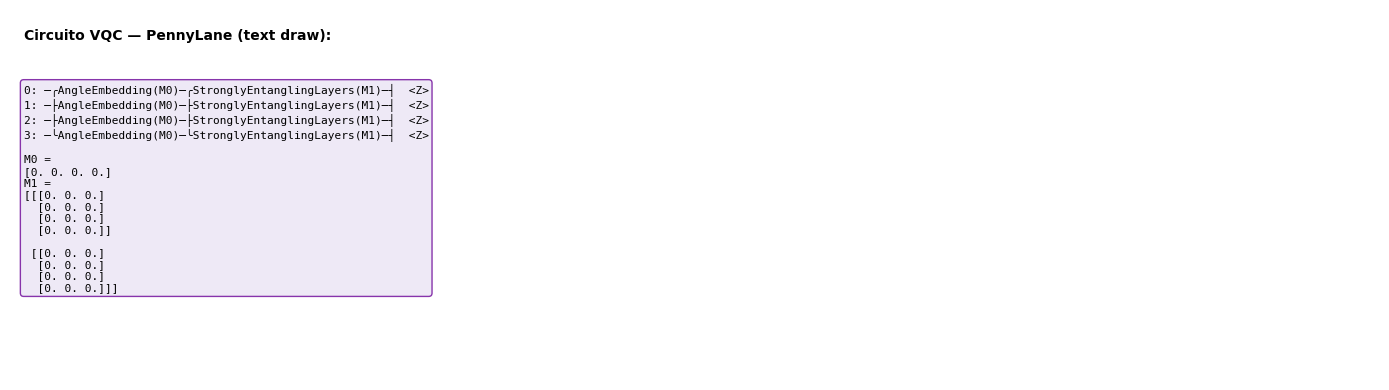


Circuito (texto):
0: ─╭AngleEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
2: ─├AngleEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤  <Z>
3: ─╰AngleEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤  <Z>

M0 = 
[0. 0. 0. 0.]
M1 = 
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]


In [10]:
fig_pl, ax_pl = plt.subplots(figsize=(14, 4))
ax_pl.axis('off')

# Dibuja el circuito con drawer de PennyLane
drawer_str = qml.draw(quantum_circuit)(
    inputs  = np.zeros(N_QUBITS),
    weights = np.zeros(qml.StronglyEntanglingLayers.shape(N_LAYERS, N_QUBITS))
)
ax_pl.text(0.01, 0.95, "Circuito VQC — PennyLane (text draw):",
           transform=ax_pl.transAxes, fontsize=10, fontweight='bold', va='top')
ax_pl.text(0.01, 0.80, drawer_str,
           transform=ax_pl.transAxes, fontsize=8, va='top',
           fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='#EDE7F6', edgecolor='#7B1FA2', alpha=0.9))
plt.tight_layout()
plt.show()
print("\nCircuito (texto):")
print(drawer_str)


### 5.2 Visualización del circuito con Qiskit

El mismo ansatz se reconstruye manualmente en Qiskit para mostrar su estructura visual con `circuit.draw(output='mpl')`:

- **Capa 1 — Encoding:** `RY(θᵢ)` en cada qubit (AngleEmbedding)  
- **Capa 2 — Entrelazamiento 1:** `RX(φᵢ)` + CNOT en cadena (periodic)  
- **Capa 3 — Entrelazamiento 2:** `RZ(ψᵢ)` + CNOT salteados


In [11]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter as QP
import matplotlib
matplotlib.use('Agg')

n_q = N_QUBITS

qc = QuantumCircuit(n_q)
qc.name = "QCPINN VQC"

# ── Encoding layer (AngleEmbedding → RY) ─────────────────────────────────────
theta_enc = [QP(f'θ_{i}') for i in range(n_q)]
for i, th in enumerate(theta_enc):
    qc.ry(th, i)
qc.barrier(label='Encoding')

# ── Entangling Layer 1 ────────────────────────────────────────────────────────
phi1 = [QP(f'φ1_{i}') for i in range(n_q)]
psi1 = [QP(f'ψ1_{i}') for i in range(n_q)]
xi1  = [QP(f'ξ1_{i}') for i in range(n_q)]
for i in range(n_q):
    qc.rz(phi1[i], i)
    qc.ry(psi1[i], i)
    qc.rz(xi1[i], i)
for i in range(n_q):
    qc.cx(i, (i + 1) % n_q)
qc.barrier(label='Layer 1')

# ── Entangling Layer 2 ────────────────────────────────────────────────────────
phi2 = [QP(f'φ2_{i}') for i in range(n_q)]
psi2 = [QP(f'ψ2_{i}') for i in range(n_q)]
xi2  = [QP(f'ξ2_{i}') for i in range(n_q)]
for i in range(n_q):
    qc.rz(phi2[i], i)
    qc.ry(psi2[i], i)
    qc.rz(xi2[i], i)
for i in range(n_q):
    qc.cx(i, (i + 1) % n_q)
qc.barrier(label='Layer 2')

print(f"Qubits   : {qc.num_qubits}")
print(f"Puertas  : {qc.count_ops()}")
print(f"Depth    : {qc.depth()}")
print(f"Paráms   : {qc.num_parameters}")

fig_qk = qc.draw(output='mpl',
                 style={'backgroundcolor': '#F3E5F5',
                        'gatefacecolor': '#CE93D8',
                        'gatecolor': '#4A148C',
                        'textcolor': '#1A237E',
                        'linecolor': '#4A148C'},
                 fold=60,
                 plot_barriers=True)
fig_qk.set_facecolor('#F8F0FE')
fig_qk.suptitle('Circuito QCPINN — Qiskit (StronglyEntanglingLayers × 2)',
                fontsize=12, fontweight='bold', color='#4A148C')
plt.tight_layout()
plt.show()


Qubits   : 4
Puertas  : OrderedDict({'rz': 16, 'ry': 12, 'cx': 8, 'barrier': 3})
Depth    : 15
Paráms   : 28


### 5.3 Diagrama completo de la arquitectura QCPINN

In [12]:
def draw_qcpinn_full():
    fig, ax = plt.subplots(figsize=(16, 6))
    ax.set_xlim(0, 16); ax.set_ylim(0, 6)
    ax.axis('off'); ax.set_facecolor('#FAF7FF'); fig.patch.set_facecolor('#FAF7FF')

    def box(x, y, w, h, title, sub='', fc='#7B1FA2', ec='white', alpha=0.9, fs=9):
        r = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                          linewidth=2, alpha=alpha, zorder=3)
        ax.add_patch(r)
        ax.text(x+w/2, y+h/2+(0.12 if sub else 0), title, ha='center', va='center',
                fontsize=fs, color='white', fontweight='bold', zorder=4)
        if sub:
            ax.text(x+w/2, y+h/2-0.2, sub, ha='center', va='center',
                    fontsize=7, color='#ddd', zorder=4)

    def arr(x1, x2, y=3.0, color='#555', lw=2):
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw), zorder=5)

    # Input
    box(0.2, 2.5, 1.0, 1.0, 't', 'ℝ¹', '#1565C0')
    arr(1.2, 1.8)

    # Pre-encode
    box(1.8, 2.0, 2.0, 2.0, 'Pre-encode', 'fc₁→fc₄  + Tanh', '#1976D2')
    ax.text(2.8, 1.7, 'ℝ¹→ℝ⁴', ha='center', fontsize=8, color='#1976D2')
    arr(3.8, 4.5)

    # Quantum block
    qbox_fc = '#7B1FA2'
    box(4.5, 1.3, 4.5, 3.4, '', '', '#EDE7F6', '#7B1FA2', 0.4)
    ax.text(6.75, 4.9, '— Bloque Cuántico (VQC 4 qubits) —', ha='center',
            fontsize=10, color='#7B1FA2', fontweight='bold')

    # Qubits inside quantum block
    qubit_ys = np.linspace(1.8, 4.2, 4)
    for i, yq in enumerate(qubit_ys):
        ax.plot([4.7, 8.7], [yq, yq], color='#7B1FA2', lw=1.5, alpha=0.5, zorder=2)
        ax.text(4.55, yq, f'q{i}', ha='right', fontsize=8, color='#7B1FA2')

    # Encoding gates
    for i, yq in enumerate(qubit_ys):
        r = plt.Rectangle((4.7, yq-0.22), 0.7, 0.44, facecolor='#CE93D8',
                          edgecolor='#7B1FA2', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(5.05, yq, r'$RY$', ha='center', fontsize=7.5,
                color='white', fontweight='bold', zorder=4)

    # Layer 1: RZ-RY-RZ + CNOT chain
    for i, yq in enumerate(qubit_ys):
        r = plt.Rectangle((5.6, yq-0.22), 0.7, 0.44, facecolor='#9C27B0',
                          edgecolor='#7B1FA2', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(5.95, yq, 'RZR YRZ', ha='center', fontsize=6, color='white',
                fontweight='bold', zorder=4)
    for i in range(len(qubit_ys)-1):
        mid = (qubit_ys[i] + qubit_ys[i+1]) / 2
        ax.plot([6.55, 6.55], [qubit_ys[i], qubit_ys[i+1]], 'k-', lw=2, zorder=4)
        ax.plot(6.55, qubit_ys[i], 'ko', ms=6, zorder=5)
        circle = plt.Circle((6.55, qubit_ys[i+1]), 0.12, color='k',
                            fill=False, lw=2, zorder=5)
        ax.add_patch(circle)
        ax.plot(6.55, qubit_ys[i+1], 'k+', ms=10, lw=2, zorder=6)

    # Layer 2
    for i, yq in enumerate(qubit_ys):
        r = plt.Rectangle((6.9, yq-0.22), 0.7, 0.44, facecolor='#6A1B9A',
                          edgecolor='#7B1FA2', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(7.25, yq, 'RZR YRZ', ha='center', fontsize=6, color='white',
                fontweight='bold', zorder=4)
    for i in range(len(qubit_ys)-1):
        ax.plot([7.85, 7.85], [qubit_ys[i+1], qubit_ys[i]], 'k-', lw=2, zorder=4)
        ax.plot(7.85, qubit_ys[i+1], 'ko', ms=6, zorder=5)
        circle2 = plt.Circle((7.85, qubit_ys[i]), 0.12, color='k',
                              fill=False, lw=2, zorder=5)
        ax.add_patch(circle2)
        ax.plot(7.85, qubit_ys[i], 'k+', ms=10, lw=2, zorder=6)

    # Measurements
    for i, yq in enumerate(qubit_ys):
        r = plt.Rectangle((8.25, yq-0.22), 0.55, 0.44, facecolor='#4CAF50',
                          edgecolor='#2E7D32', lw=1.5, zorder=3)
        ax.add_patch(r)
        ax.text(8.525, yq, '$<Z>$', ha='center', fontsize=7,
                color='white', fontweight='bold', zorder=4)

    arr(8.8, 9.5)
    ax.text(9.15, 3.35, 'ℝ⁴', ha='center', fontsize=8, color='#555')

    # Post-proc
    box(9.5, 2.0, 2.2, 2.0, 'Post-proc', 'fc₄→fc₂  + Tanh', '#1976D2')
    ax.text(10.6, 1.7, 'ℝ⁴→ℝ²', ha='center', fontsize=8, color='#1976D2')
    arr(11.7, 12.4)

    # Output
    box(12.4, 2.5, 1.6, 1.0, 'D̂ₕ, D̂ᵥᵥ', 'ℝ²', '#E53935')

    # Physics loss
    ax.annotate('', xy=(13.2, 2.5), xytext=(13.2, 1.4),
                arrowprops=dict(arrowstyle='<-', color='#E91E63', lw=2), zorder=5)
    ax.text(13.2, 1.1, 'autograd  ∂D/∂t', ha='center', fontsize=8,
            color='#E91E63', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='#FCE4EC', edgecolor='#E91E63'))

    # Loss box
    box(9.5, 0.15, 5.2, 0.9,
        r'$\mathcal{L} = \lambda_{data}\mathcal{L}_{MSE} + \lambda_{phys}\mathcal{L}_{phys}$',
        '', '#388E3C', '#1B5E20', 0.85, fs=9)

    ax.set_title('Arquitectura QCPINN — Quantum-Classical Physics-Informed Neural Network',
                 fontsize=13, fontweight='bold', color='#4A148C', pad=15)
    plt.tight_layout()
    plt.show()

draw_qcpinn_full()


### 5.4 Entrenamiento de la QCPINN

In [13]:
def qcpinn_loss(model, t_data, y_data, t_phys, lambda_data=1.0, lambda_phys=0.5):
    y_pred = model(t_data)
    l_data = nn.MSELoss()(y_pred, y_data)
    t_p = t_phys.clone().requires_grad_(True)
    y_p = model(t_p)
    dD_dt_h = torch.autograd.grad(y_p[:, 0].sum(), t_p,
                                   create_graph=True, retain_graph=True)[0]
    dD_dt_w = torch.autograd.grad(y_p[:, 1].sum(), t_p,
                                   create_graph=True, retain_graph=True)[0]
    loss_phys = (torch.relu(dD_dt_h)**2).mean() + (torch.relu(dD_dt_w)**2).mean()
    total = lambda_data * l_data + lambda_phys * loss_phys
    return total, l_data, loss_phys

torch.manual_seed(42)
qcpinn            = QCPINN()
optimizer_qcpinn  = torch.optim.Adam(qcpinn.parameters(), lr=5e-3)
scheduler_qcpinn  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_qcpinn, T_max=1000, eta_min=1e-4)

history_qcpinn = []
N_EPOCHS_QC    = 3000   # reducido: el VQC es más costoso computacionalmente

print("Entrenando QCPINN (puede tardar varios minutos en CPU)...")
for epoch in range(N_EPOCHS_QC):
    optimizer_qcpinn.zero_grad()
    loss, l_d, l_p = qcpinn_loss(qcpinn, t, y, t.clone())
    loss.backward()
    optimizer_qcpinn.step()
    scheduler_qcpinn.step()
    history_qcpinn.append((loss.item(), l_d.item(), l_p.item()))
    if epoch % 500 == 0 or epoch == N_EPOCHS_QC - 1:
        print(f'Epoch {epoch:4d} | Total: {loss.item():.5f} '
              f'| Data: {l_d.item():.5f}  | Phys: {l_p.item():.5f}')


Entrenando QCPINN (puede tardar varios minutos en CPU)...
Epoch    0 | Total: 0.87421 | Data: 0.87382  | Phys: 0.00078
Epoch  500 | Total: 0.00779 | Data: 0.00779  | Phys: 0.00000
Epoch 1000 | Total: 0.00606 | Data: 0.00602  | Phys: 0.00008
Epoch 1500 | Total: 0.00341 | Data: 0.00338  | Phys: 0.00006
Epoch 2000 | Total: 0.00072 | Data: 0.00070  | Phys: 0.00003
Epoch 2500 | Total: 0.00038 | Data: 0.00037  | Phys: 0.00002
Epoch 2999 | Total: 0.00032 | Data: 0.00031  | Phys: 0.00002


## 6. Comparación de todos los modelos

Panel principal: ajuste de curvas $D_{L1}(t)$ con cruce marcado.  
Paneles secundarios: historia de pérdida, zoom en $t^*$, relación $\\dot{D}$ vs $D$, y métricas cuantitativas.


In [14]:
ode_func.eval(); pinn.eval(); qcpinn.eval()

with torch.no_grad():
    y_pred_ode   = rk4_integrate(ode_func, y[0], t).numpy()
    y_pred_pinn  = pinn(t).numpy()
    y_pred_qcpinn = qcpinn(t).numpy()

# ─── Métricas ────────────────────────────────────────────────────────────────
def mse(pred, true):
    return float(np.mean((pred - true)**2))

def rmse(pred, true):
    return float(np.sqrt(np.mean((pred - true)**2)))

def mae(pred, true):
    return float(np.mean(np.abs(pred - true)))

metrics = {}
for name, pred in [('Neural ODE', y_pred_ode),
                   ('PINN',       y_pred_pinn),
                   ('QCPINN',     y_pred_qcpinn)]:
    metrics[name] = {
        'MSE_h':  mse(pred[:,0],  Dh_np),
        'MSE_w':  mse(pred[:,1],  Dw_np),
        'RMSE_h': rmse(pred[:,0], Dh_np),
        'RMSE_w': rmse(pred[:,1], Dw_np),
        'MAE_h':  mae(pred[:,0],  Dh_np),
        'MAE_w':  mae(pred[:,1],  Dw_np),
    }

print("\n" + "="*65)
print(f"{'Métrica':<20} {'Neural ODE':>12} {'PINN':>12} {'QCPINN':>12}")
print('-'*56)
for m in ['MSE_h','MSE_w','RMSE_h','RMSE_w','MAE_h','MAE_w']:
    vals = [metrics[n][m] for n in ['Neural ODE','PINN','QCPINN']]
    print(f"{m:<20} {vals[0]:>12.6f} {vals[1]:>12.6f} {vals[2]:>12.6f}")
print('='*56)



Métrica                Neural ODE         PINN       QCPINN
--------------------------------------------------------
MSE_h                    0.002351     0.000027     0.000517
MSE_w                    0.000562     0.000051     0.000099
RMSE_h                   0.048488     0.005195     0.022730
RMSE_w                   0.023703     0.007107     0.009971
MAE_h                    0.019051     0.002759     0.011830
MAE_w                    0.012905     0.002938     0.006362


In [15]:
# ─── Detección cruce en predicciones ─────────────────────────────────────────
def find_cross(a1, a2, tv):
    d = a1 - a2
    idx = np.where(np.diff(np.sign(d)))[0]
    return tv[idx] if len(idx) else np.array([])

t_cross_ode    = find_cross(y_pred_ode[:,0],    y_pred_ode[:,1],    t_np)
t_cross_pinn   = find_cross(y_pred_pinn[:,0],   y_pred_pinn[:,1],   t_np)
t_cross_qcpinn = find_cross(y_pred_qcpinn[:,0], y_pred_qcpinn[:,1], t_np)

print("Cruce t* detectado en cada modelo (Efecto Mpemba):")
print(f"  Datos originales : {t_cross}")
print(f"  Neural ODE       : {t_cross_ode}")
print(f"  PINN             : {t_cross_pinn}")
print(f"  QCPINN           : {t_cross_qcpinn}")


Cruce t* detectado en cada modelo (Efecto Mpemba):
  Datos originales : [0.03   0.0425]
  Neural ODE       : []
  PINN             : []
  QCPINN           : []


In [16]:
# ─── Figura de comparación completa ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.32)

ax_main   = fig.add_subplot(gs[0, :])
ax_loss   = fig.add_subplot(gs[1, 0])
ax_zoom   = fig.add_subplot(gs[1, 1])
ax_sr     = fig.add_subplot(gs[1, 2])
ax_met    = fig.add_subplot(gs[2, 0:2])
ax_mono   = fig.add_subplot(gs[2, 2])

colors_hot  = {'Neural ODE': '#E53935', 'PINN': '#FF7043', 'QCPINN': '#AD1457'}
colors_warm = {'Neural ODE': '#1E88E5', 'PINN': '#039BE5', 'QCPINN': '#6A1B9A'}
styles      = {'Neural ODE': '-', 'PINN': '--', 'QCPINN': '-.'}

# ── Panel 1: curvas completas ──────────────────────────────────────────────
ax = ax_main
ax.plot(t_np, Dh_np, 'r:',  lw=2.0, alpha=0.5, label=r'$D_{L1}^{hot}$ (simulación)')
ax.plot(t_np, Dw_np, 'b:',  lw=2.0, alpha=0.5, label=r'$D_{L1}^{warm}$ (simulación)')

for name, pred in [('Neural ODE', y_pred_ode),
                   ('PINN',       y_pred_pinn),
                   ('QCPINN',     y_pred_qcpinn)]:
    ls = styles[name]
    ax.plot(t_np, pred[:,0], color=colors_hot[name],  ls=ls, lw=1.8,
            label=f'{name} — hot')
    ax.plot(t_np, pred[:,1], color=colors_warm[name], ls=ls, lw=1.8,
            label=f'{name} — warm')

for tc in t_cross:
    ax.axvline(tc, color='gray', ls='--', lw=1.5, alpha=0.8,
               label=f'$t^*={tc:.3f}$ s (datos)')
ax.set_xlabel('t (s)', fontsize=11); ax.set_ylabel(r'$D_{L1}$', fontsize=11)
ax.set_title('Ajuste de curvas de relajación — comparación Neural ODE / PINN / QCPINN',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=7.5, ncol=4, loc='upper right'); ax.grid(True, alpha=0.3)

# ── Panel 2: historia de pérdida ───────────────────────────────────────────
ax = ax_loss
ax.semilogy(history_ode, color='#43A047', lw=1.4, label='Neural ODE')
ax.semilogy([h[0] for h in history_pinn],   color='#FB8C00', lw=1.4, label='PINN (total)')
ax.semilogy([h[1] for h in history_pinn],   color='#FB8C00', lw=0.9, ls='--', alpha=0.6, label='PINN (data)')
ax.semilogy([h[2] for h in history_pinn],   color='#FB8C00', lw=0.9, ls=':',  alpha=0.6, label='PINN (phys)')
ax.semilogy([h[0] for h in history_qcpinn], color='#7B1FA2', lw=1.4, label='QCPINN (total)')
ax.semilogy([h[1] for h in history_qcpinn], color='#7B1FA2', lw=0.9, ls='--', alpha=0.6, label='QCPINN (data)')
ax.set_xlabel('Epoch', fontsize=10); ax.set_ylabel('Loss', fontsize=10)
ax.set_title('Historia de entrenamiento', fontsize=11)
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# ── Panel 3: zoom en zona de cruce ────────────────────────────────────────
ax = ax_zoom
mask_z = (t_np >= 0.01) & (t_np <= 0.10)
ax.plot(t_np[mask_z], Dh_np[mask_z], 'r:', lw=2, alpha=0.5, label='Data hot')
ax.plot(t_np[mask_z], Dw_np[mask_z], 'b:', lw=2, alpha=0.5, label='Data warm')
for name, pred in [('Neural ODE', y_pred_ode),
                   ('PINN',       y_pred_pinn),
                   ('QCPINN',     y_pred_qcpinn)]:
    ax.plot(t_np[mask_z], pred[mask_z,0], color=colors_hot[name],
            ls=styles[name], lw=1.5, label=f'{name} hot')
    ax.plot(t_np[mask_z], pred[mask_z,1], color=colors_warm[name],
            ls=styles[name], lw=1.5, label=f'{name} warm')
for tc in t_cross:
    ax.axvline(tc, color='gray', ls='--', lw=1.2)
ax.set_xlabel('t (s)', fontsize=10); ax.set_ylabel(r'$D_{L1}$', fontsize=10)
ax.set_title(r'Zoom — zona de cruce ($t^*$)', fontsize=11)
ax.legend(fontsize=6.5, ncol=2); ax.grid(True, alpha=0.3)

# ── Panel 4: dD/dt vs D (SR) ──────────────────────────────────────────────
ax = ax_sr
ax.scatter(D_h_slow, dDh_slow, s=8, alpha=0.45, color='tomato',
           label=r'$dD_h/dt$ numérico ($t>0.05$ s)')
D_sort = np.sort(D_h_slow)
try:
    ax.plot(D_sort, model_sr_predict(D_sort), 'k-', lw=2, label='PySR / Fallback')
except Exception:
    pass
ax.set_xlabel(r'$D_{L1}$', fontsize=10); ax.set_ylabel(r'$dD_{L1}/dt$', fontsize=10)
ax.set_title(r'Relación $\dot{D}$ vs $D$ — PySR', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── Panel 5: Barras de métricas ───────────────────────────────────────────
ax = ax_met
model_names = ['Neural ODE', 'PINN', 'QCPINN']
x = np.arange(len(model_names))
w = 0.25
rmse_h = [metrics[m]['RMSE_h'] for m in model_names]
rmse_w = [metrics[m]['RMSE_w'] for m in model_names]
mae_h  = [metrics[m]['MAE_h']  for m in model_names]

bars_h = ax.bar(x - w,   rmse_h, w, label='RMSE hot',  color='#E53935', alpha=0.85)
bars_w = ax.bar(x,       rmse_w, w, label='RMSE warm', color='#1E88E5', alpha=0.85)
bars_m = ax.bar(x + w,   mae_h,  w, label='MAE hot',   color='#F9A825', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Error', fontsize=10)
ax.set_title('Métricas cuantitativas por modelo', fontsize=11)
for bars in [bars_h, bars_w, bars_m]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.0005,
                f'{h:.4f}', ha='center', va='bottom', fontsize=7)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')

# ── Panel 6: Monotonicidad ────────────────────────────────────────────────
ax = ax_mono
dDh_ode  = np.gradient(y_pred_ode[:,0], t_np)
dDh_pinn = np.gradient(y_pred_pinn[:,0], t_np)
dDh_qc   = np.gradient(y_pred_qcpinn[:,0], t_np)

ax.plot(t_np, dDh_ode,  color='#43A047', lw=1.4, label='Neural ODE')
ax.plot(t_np, dDh_pinn, color='#FB8C00', lw=1.4, ls='--', label='PINN')
ax.plot(t_np, dDh_qc,   color='#7B1FA2', lw=1.4, ls='-.', label='QCPINN')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.fill_between(t_np, 0, np.maximum(dDh_ode, 0), alpha=0.15, color='#43A047')
ax.fill_between(t_np, 0, np.maximum(dDh_pinn, 0), alpha=0.15, color='#FB8C00')
ax.fill_between(t_np, 0, np.maximum(dDh_qc, 0), alpha=0.15, color='#7B1FA2')
ax.set_xlabel('t (s)', fontsize=10)
ax.set_ylabel(r'$d\hat{D}_h/dt$', fontsize=10)
ax.set_title('Monotonicidad de las predicciones (hot)', fontsize=11)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.text(0.02, 0.05, 'Violaciones (>0) sombreadas', transform=ax.transAxes,
        fontsize=8, color='gray')

plt.suptitle('Comparación completa — Kumar & Bechhoefer (2020):\nNeural ODE · PINN · QCPINN',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('mpemba_comparison_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada como 'mpemba_comparison_all.png'")


Figura guardada como 'mpemba_comparison_all.png'


## 7. Extracción de $\\lambda_2$ y comparación con las predicciones

A tiempos largos: $D(t) \\approx |a_2|\\,V\\,e^{-\\lambda_2 t} + D_\\infty$


In [17]:
def exp_decay(t, A, lam, D_inf):
    return A * np.exp(-lam * t) + D_inf

mask_fit = t_np > 0.05
lambdas  = {}

for label, D_arr in [('hot', Dh_np), ('warm', Dw_np)]:
    try:
        p0   = [D_arr[mask_fit][0] - D_arr[-10:].mean(), 5.0, D_arr[-10:].mean()]
        popt, pcov = curve_fit(exp_decay, t_np[mask_fit], D_arr[mask_fit],
                               p0=p0, maxfev=8000)
        A, lam, D_inf = popt
        perr = np.sqrt(np.diag(pcov))
        lambdas[label] = lam
        print(f'[{label:4s}]  A  = {A:.5f} ± {perr[0]:.5f}')
        print(f'        λ₂ = {lam:.4f} ± {perr[1]:.4f}  →  τ = 1/λ₂ = {1/lam:.4f} s')
        print(f'        D∞ = {D_inf:.5f} ± {perr[2]:.5f}\n')
    except RuntimeError as e:
        print(f'[{label}] Ajuste no convergió: {e}')

# Verificar lo que aprendió la Neural ODE
D_mid_h = float(Dh_np[mask_fit].mean())
D_mid_w = float(Dw_np[mask_fit].mean())
D_tensor = torch.tensor([D_mid_h, D_mid_w])
with torch.no_grad():
    dD_pred = ode_func(D_tensor).numpy()

print('─── Verificación Neural ODE ───────────────────────────')
for label, D_mid, dD, lam_key in [
    ('hot',  D_mid_h, dD_pred[0], 'hot'),
    ('warm', D_mid_w, dD_pred[1], 'warm')]:
    lam = lambdas.get(lam_key, float('nan'))
    slope_expected = -lam * D_mid
    print(f'[{label:4s}]  ODE f(D_mid)={dD:.5f}   esperado(-λ₂·D)={slope_expected:.5f}')


[hot ]  A  = 0.18987 ± 0.00337
        λ₂ = 19.7047 ± 0.2418  →  τ = 1/λ₂ = 0.0507 s
        D∞ = 0.62733 ± 0.00011

[warm]  A  = 0.37295 ± 0.00408
        λ₂ = 21.8897 ± 0.1526  →  τ = 1/λ₂ = 0.0457 s
        D∞ = 0.56676 ± 0.00011

─── Verificación Neural ODE ───────────────────────────
[hot ]  ODE f(D_mid)=-0.32565   esperado(-λ₂·D)=-12.51495
[warm]  ODE f(D_mid)=-0.29861   esperado(-λ₂·D)=-12.67615


## 8. Resumen comparativo final

| Aspecto | Neural ODE (RK4) | PINN | PySR | **QCPINN** |
|---------|-----------------|------|------|------------|
| Integrador | RK4 $O(\\Delta t^5)$ | n/a | n/a | n/a |
| Restricción física | ninguna | $dD/dt \\le 0$ via autograd | ninguna | $dD/dt \\le 0$ via autograd |
| Backend | PyTorch | PyTorch | Julia/C++ | PennyLane + PyTorch |
| Qubits | — | — | — | 4 |
| Interpretabilidad | media | baja | **alta** | media-baja |
| Detecta $t^*$ | ✓ | ✓ | indirectamente | ✓ |
| Ventaja cuántica | — | — | — | exploración del espacio de Hilbert |

### Próximos pasos

1. **Si PySR confirma** $\\dot{D} \\approx -kD$: reemplaza la restricción en PINN/QCPINN por residuo `dD/dt + k*D = 0`.
2. **Extender al régimen KL**: verificar que el cruce es independiente de la métrica (Extended Data Fig. 7 del paper).
3. **Más qubits / capas**: escalar el VQC a 6–8 qubits con `default.qubit` o hardware real (IBM).
4. **Inverse Mpemba**: usar la QCPINN para buscar condiciones iniciales que aceleran el calentamiento (predicción de Gal & Raz, PRL 2020).
5. **torchdiffeq**: reemplazar el integrador RK4 manual por el método adjunto para gradientes exactos en secuencias largas.


In [18]:
# ─── Tabla de métricas final en consola ──────────────────────────────────────
import pandas as pd

rows = []
for name in ['Neural ODE', 'PINN', 'QCPINN']:
    m = metrics[name]
    rows.append({
        'Modelo':   name,
        'RMSE_hot': f"{m['RMSE_h']:.5f}",
        'RMSE_warm':f"{m['RMSE_w']:.5f}",
        'MAE_hot':  f"{m['MAE_h']:.5f}",
        'MAE_warm': f"{m['MAE_w']:.5f}",
        'MSE_hot':  f"{m['MSE_h']:.6f}",
        'MSE_warm': f"{m['MSE_w']:.6f}",
        't*_detectado': str({
            'Neural ODE': t_cross_ode,
            'PINN':       t_cross_pinn,
            'QCPINN':     t_cross_qcpinn
        }.get(name, [])),
    })

df_res = pd.DataFrame(rows).set_index('Modelo')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("\n" + "="*90)
print("TABLA DE RESULTADOS — Efecto Mpemba en Sistema Coloidal")
print("="*90)
print(df_res.to_string())
print("="*90)



TABLA DE RESULTADOS — Efecto Mpemba en Sistema Coloidal
           RMSE_hot RMSE_warm  MAE_hot MAE_warm   MSE_hot  MSE_warm t*_detectado
Modelo                                                                          
Neural ODE  0.04849   0.02370  0.01905  0.01291  0.002351  0.000562           []
PINN        0.00520   0.00711  0.00276  0.00294  0.000027  0.000051           []
QCPINN      0.02273   0.00997  0.01183  0.00636  0.000517  0.000099           []
